In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from sklearn.metrics import jaccard_score
from matplotlib.patches import Patch

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

pivot_gdd = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_output_explainability/gdd_cancer_gene_matrix_raw.csv", index_col="ground_truth")
pivot_o3_mini = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_output_explainability/o3_mini_cancer_gene_matrix_raw.csv", index_col="ground_truth")
pivot_norm_col_gdd = pivot_gdd.div(pivot_gdd.sum(axis=0), axis=1)
pivot_norm_row_gdd = pivot_gdd.div(pivot_gdd.sum(axis=1), axis=0)
pivot_norm_col_o3_mini = pivot_o3_mini.div(pivot_o3_mini.sum(axis=0), axis=1)
pivot_norm_row_o3_mini = pivot_o3_mini.div(pivot_o3_mini.sum(axis=1), axis=0)

# Find the top genes with the highest total counts across all cancers
top_gene_num = 50
top_genes = pivot_gdd.sum(axis=0).sort_values(ascending=False).head(top_gene_num).index

# Subset the matrix to just these top genes
subset_gdd = pivot_norm_col_gdd[top_genes]
subset_o3_mini = pivot_norm_col_o3_mini[top_genes]

In [2]:
R, C = subset_gdd.shape
A = subset_gdd.to_numpy()

# --- Maximize diagonal on subset_gdd via assignment (Hungarian); fallback = greedy ---
try:
    from scipy.optimize import linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(-A)  # maximize A
except Exception:
    rows_by_peak = np.argsort(A.max(axis=1))[::-1]
    unused = set(range(C))
    row_ind, col_ind = [], []
    for i in rows_by_peak:
        j = max(unused, key=lambda k: A[i, k])
        row_ind.append(i); col_ind.append(j)
        unused.remove(j)
    row_ind, col_ind = np.array(row_ind), np.array(col_ind)

# # --- Order BOTH rows & columns by diagonal strength (largest first) ---
pairs = sorted(zip(row_ind, col_ind), key=lambda rc: A[rc[0], rc[1]], reverse=True)
diag_rows = [r for r, c in pairs]
diag_cols = [c for r, c in pairs]

ordered_rows  = list(subset_gdd.index[diag_rows])           # reorder cancers

# --- Stop after Pancreatic Cancer ---
try:
    pancreatic_idx = ordered_rows.index("Pancreatic Cancer")
    ordered_rows = ordered_rows[:pancreatic_idx + 1]
except ValueError:
    # If "Pancreatic Cancer" not found, keep all rows
    pass

# --- NEW: clustered-diagonal gene order --------------------------------------
# Use the average signal of the two matrices as the "affinity" for assignment.
affinity = (subset_gdd + subset_o3_mini) / 2.0
affinity = affinity.loc[ordered_rows]  # align rows to your chosen order

# For each gene, find the cancer row with the strongest signal (argmax),
# and compute a "specificity margin" = top - second-best.
primary_row_for_gene = affinity.idxmax(axis=0)                # gene -> cancer (row label)
top_vals   = affinity.max(axis=0)
second_vals = affinity.apply(lambda col: col.nlargest(2).iloc[1] if (col > 0).sum() >= 2 else 0.0, axis=0)
margin = top_vals - second_vals                                # larger = more specific

# Build column order: concatenate blocks in the same order as rows.
ordered_genes_clustered = []
for cancer in ordered_rows:
    genes_in_block = [g for g in affinity.columns if primary_row_for_gene[g] == cancer]
    # Within each block, sort by specificity margin, then by the actual value for that row.
    genes_in_block.sort(key=lambda g: (-(margin[g]), -affinity.loc[cancer, g]))
    ordered_genes_clustered.extend(genes_in_block)

# Fallback for any genes that didn't get picked up (should be none, but just in case)
remaining = [g for g in affinity.columns if g not in set(ordered_genes_clustered)]
ordered_genes_clustered += sorted(remaining, key=lambda g: affinity[g].sum(), reverse=True)

# Reorder both matrices with this clustered-diagonal column order
gdd_sorted = subset_gdd.loc[ordered_rows, ordered_genes_clustered]
o3_sorted  = subset_o3_mini.loc[ordered_rows, ordered_genes_clustered]

# (your interleaving + plotting code stays the same)
rows, labels = [], []
for name in ordered_rows:
    rows.append(gdd_sorted.loc[name]); labels.append(f"{name} — GDD-ENS")
    rows.append(o3_sorted.loc[name]);  labels.append(f"{name} — GPT-5")
interleaved = pd.DataFrame(rows, columns=ordered_genes_clustered, index=labels).fillna(0.0)


# --- plot (Matplotlib only) ---
fig_w = max(30, interleaved.shape[1] * 1)
fig_h = max(12,  0.30 * interleaved.shape[0])
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)
# ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
#                       'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
#                       'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']
# im = ax.imshow(interleaved.values, aspect="auto", cmap="OrRd")
# --- make exact zeros pure white -------------------------------------------
data = interleaved.values
zero_mask = np.isclose(data, 0.0, atol=1e-12)        # treat exact (or near) zeros as zero
data_masked = np.ma.array(data, mask=zero_mask)      # mask them

cmap = plt.cm.get_cmap("OrRd").copy()
cmap.set_bad("white")                                # masked values show as white

# keep color scale for positive values only
pos = data[~zero_mask]
vmin = pos.min() if pos.size else 0.0
vmax = pos.max() if pos.size else 1.0

im = ax.imshow(data_masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

ax.set_xticks(np.arange(interleaved.shape[1]))
ax.set_xticklabels(interleaved.columns, rotation=45, ha='right', fontsize=36)

# Map each gene to its cluster (primary cancer). Anything not assigned -> "Shared/Misc".
gene_to_cluster = {g: primary_row_for_gene.get(g, "Shared/Misc")
                   for g in ordered_genes_clustered}

# Build a consistent color for each cancer in the same order as your row blocks
cmap_colors = plt.get_cmap("tab20")
cluster_colors = {row: cmap_colors(i % cmap_colors.N) for i, row in enumerate(ordered_rows)}
cluster_colors["Shared/Misc"] = (0.55, 0.55, 0.55, 1.0)

# Color each tick label
xtick_colors = [cluster_colors[gene_to_cluster[g]] for g in ordered_genes_clustered]
for lbl, col in zip(ax.get_xticklabels(), xtick_colors):
    lbl.set_color(col)

# (Optional) faint vertical lines between cluster blocks
col_start = 0
for row in ordered_rows:
    n_in_block = sum(1 for g in ordered_genes_clustered if gene_to_cluster[g] == row)
    if n_in_block > 0:
        ax.axvline(col_start - 0.5, color=cluster_colors[row], lw=1, alpha=1)
        col_start += n_in_block
# final right boundary
ax.axvline(col_start - 0.5, color="0.6", lw=0.6, alpha=0.25)

# (Optional) compact legend for the biggest clusters
counts = pd.Series([gene_to_cluster[g] for g in ordered_genes_clustered]).value_counts()
topK = 13  # show only the largest clusters to keep the legend readable
handles = [Patch(color=cluster_colors[c], label=f"{c} (n={counts[c]})")
           for c in counts.index[:topK]]
ax.legend(handles=handles, title="Gene cluster (primary cancer)", fontsize=32, title_fontsize=36,
          bbox_to_anchor=(1.1, 0.75), loc="upper left", frameon=False)

# --- Color y-axis labels by cancer type ---
ax.set_yticks(np.arange(interleaved.shape[0]))
ax.set_yticklabels(interleaved.index, fontsize=36)

# Extract cancer name from y-axis label (before " — ")
ytick_colors = []
for label_text in interleaved.index:
    cancer_name = label_text.split(" — ")[0]
    ytick_colors.append(cluster_colors.get(cancer_name, (0, 0, 0, 1)))

for lbl, col in zip(ax.get_yticklabels(), ytick_colors):
    lbl.set_color(col)

# light separators between each cancer pair
for r in range(2, interleaved.shape[0], 2):
    ax.axhline(r - 0.5, linewidth=0.8)


cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=32)

ax.set_title(f'Top {top_gene_num} Genes per Cancer Type (Normalized by Each Gene)', fontsize=48, fontweight='bold')

plt.tight_layout()
plt.savefig(f'interpretability_matrix_top{top_gene_num}.pdf', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3196431/2457031553.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("OrRd").copy()


In [3]:
# Ensure both matrices have same dimensions and alignment
common_cancers = pivot_gdd.index.intersection(pivot_o3_mini.index)
common_genes = pivot_gdd.columns.intersection(pivot_o3_mini.columns)

mat1_aligned = pivot_gdd.loc[common_cancers, common_genes]
mat2_aligned = pivot_o3_mini.loc[common_cancers, common_genes]

print(f"Comparing matrices with {len(common_cancers)} genes and {len(common_genes)} cancer types\n")

# 1. Overall Correlation (Element-wise)
flat1 = mat1_aligned.values.flatten()
flat2 = mat2_aligned.values.flatten()

pearson_corr, p_value = pearsonr(flat1, flat2)
spearman_corr, sp_value = spearmanr(flat1, flat2)

print("=== Overall Similarity ===")
print(f"Pearson Correlation: {pearson_corr:.4f} (p-value: {p_value:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {sp_value:.4e})")

# 2. Cosine Similarity
cosine_sim = 1 - cosine(flat1, flat2)
print(f"Cosine Similarity: {cosine_sim:.4f}")

# 3. Euclidean Distance (normalized)
euclidean_dist = np.sqrt(np.sum((mat1_aligned.values - mat2_aligned.values) ** 2))
max_possible_dist = np.sqrt(np.sum(mat1_aligned.values ** 2) + np.sum(mat2_aligned.values ** 2))
normalized_euclidean = 1 - (euclidean_dist / max_possible_dist)
print(f"Normalized Euclidean Similarity: {normalized_euclidean:.4f}\n")

# 4. Binary/Presence-Absence Comparison (if matrices are binary or can be thresholded)
# Convert to binary (presence/absence)
binary1 = (mat1_aligned > 0).astype(int).values.flatten()
binary2 = (mat2_aligned > 0).astype(int).values.flatten()

jaccard_sim = jaccard_score(binary1, binary2, average='binary')
print("=== Binary Similarity (Presence/Absence) ===")
print(f"Jaccard Similarity: {jaccard_sim:.4f}")

# Agreement percentage
agreement = np.mean(binary1 == binary2) * 100
print(f"Agreement: {agreement:.2f}%\n")

# 5. Per-Gene Correlation
print("=== Per-Cancer Correlation (Top 10 most similar cancer) ===")
cancer_correlations = []
for cancer in common_cancers:
    corr, _ = pearsonr(mat1_aligned.loc[cancer], mat2_aligned.loc[cancer])
    cancer_correlations.append((cancer, corr))

cancer_correlations.sort(key=lambda x: x[1], reverse=True)
for cancer, corr in cancer_correlations[:10]:
    print(f"{cancer}: {corr:.4f}")

# 6. Per-Cancer Correlation
print("\n=== Per-Gene Correlation ===")
gene_correlations = []
for gene in common_genes:
    corr, _ = pearsonr(mat1_aligned[gene], mat2_aligned[gene])
    gene_correlations.append((gene, corr))

gene_correlations.sort(key=lambda x: x[1], reverse=True)
for gene, corr in gene_correlations[:10]:
    print(f"{gene}: {corr:.4f}")

Comparing matrices with 34 genes and 332 cancer types

=== Overall Similarity ===
Pearson Correlation: 0.9404 (p-value: 0.0000e+00)
Spearman Correlation: 0.7869 (p-value: 0.0000e+00)
Cosine Similarity: 0.9410
Normalized Euclidean Similarity: 0.6551

=== Binary Similarity (Presence/Absence) ===
Jaccard Similarity: 0.7593
Agreement: 81.09%

=== Per-Cancer Correlation (Top 10 most similar cancer) ===
Gastrointestinal Stromal Tumor: 0.9947
Ovarian Cancer: 0.9882
Colorectal Cancer: 0.9840
Esophagogastric Cancer: 0.9836
Pancreatic Cancer: 0.9791
Retinoblastoma: 0.9778
Renal Cell Carcinoma: 0.9775
Small Cell Lung Cancer: 0.9681
CNS Cancer: 0.9674
Sex Cord Stromal Tumor: 0.9661

=== Per-Gene Correlation ===
IDH1: 0.9998
KEAP1: 0.9994
CBFB: 0.9990
STK11: 0.9990
EGFR: 0.9985
RBM10: 0.9983
NRAS: 0.9973
NKX2-1: 0.9970
VHL: 0.9970
APC: 0.9970


/tmp/ipykernel_3196431/2326679717.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


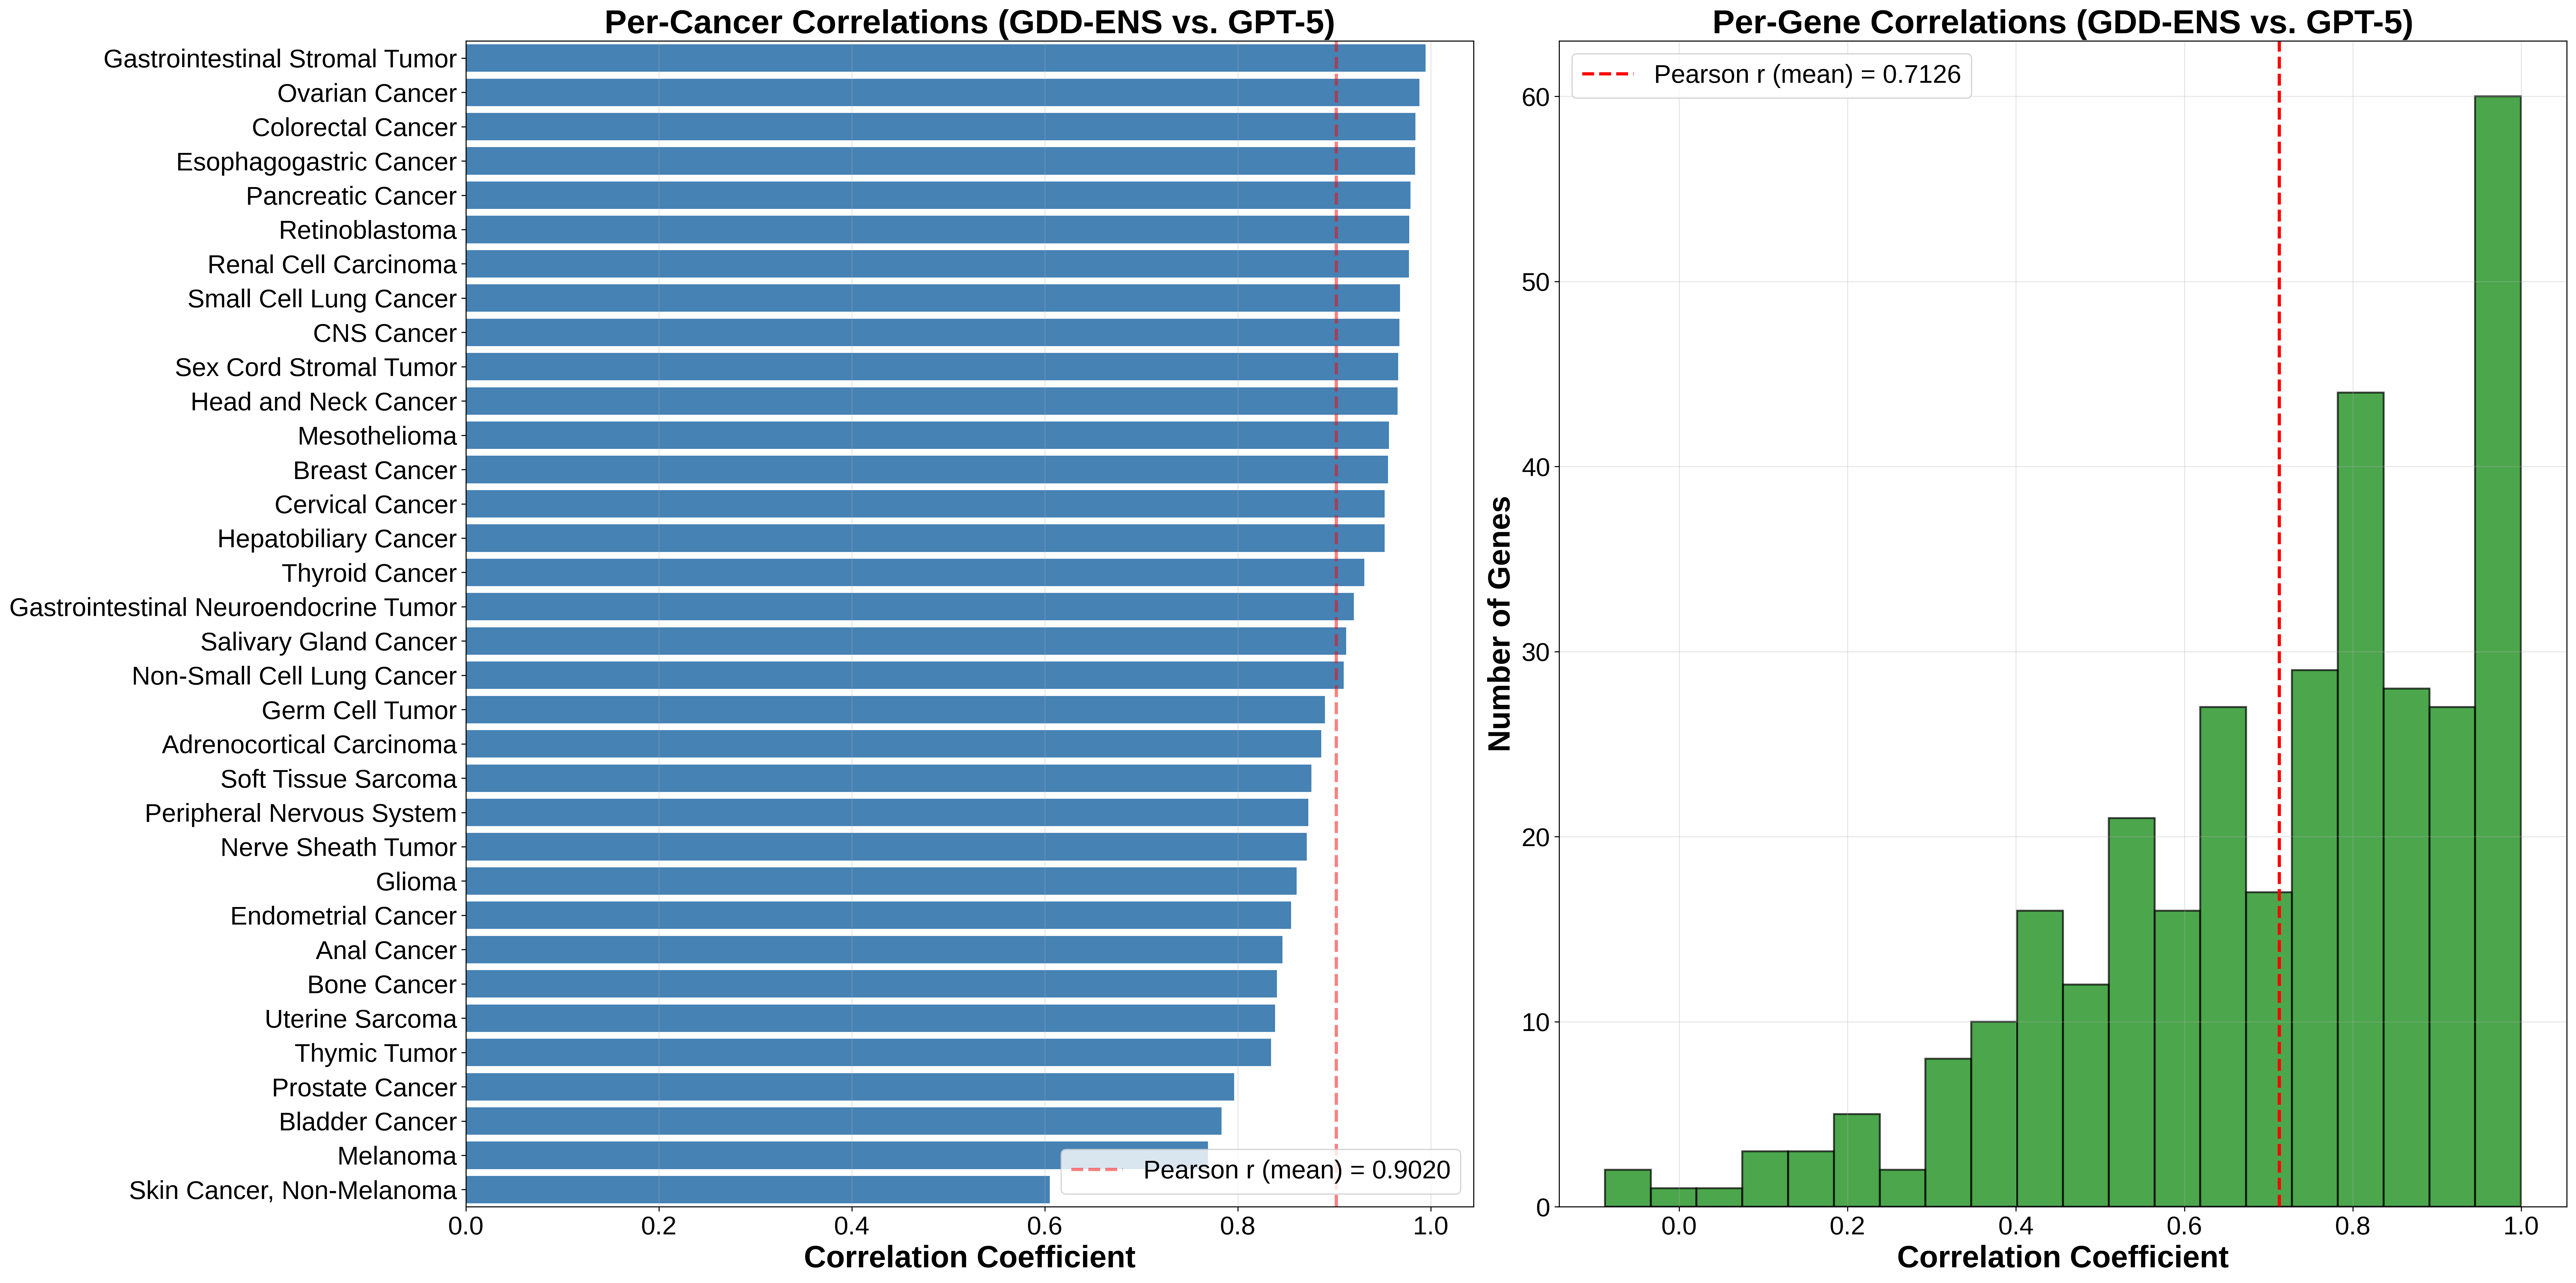

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- make a 1×2 layout (side by side) ---
fig, (ax5, ax4) = plt.subplots(
    nrows=1, ncols=2, figsize=(28, 14), dpi=300,
    gridspec_kw={"width_ratios": [2, 2]}, constrained_layout=True
)

# ===== Left: Per-cancer correlations (ascending) =====
top_10_genes = sorted(cancer_correlations, key=lambda x: x[1])  # ascending
cancer_names = [g[0] for g in top_10_genes]
cancer_corrs = [g[1] for g in top_10_genes]

ax5.barh(range(len(cancer_names)), cancer_corrs, color='steelblue')
ax5.set_yticks(range(len(cancer_names)))
ax5.tick_params(axis='x', labelsize=20)
ax5.set_yticklabels(cancer_names, fontsize=20)
ax5.set_xlabel('Correlation Coefficient', fontsize=24, fontweight='bold')
ax5.set_title('Per-Cancer Correlations (GDD-ENS vs. GPT-5)', fontsize=26, fontweight='bold')
mean_cancer = sum(cancer_corrs) / len(cancer_corrs)
ax5.axvline(mean_cancer, color='red', linestyle='--', alpha=0.5, linewidth=2.5,
            label=f'Pearson r (mean) = {mean_cancer:.4f}')
ax5.legend(loc='lower right', fontsize=20)
ax5.grid(True, alpha=0.3, axis='x')
ax5.set_ylim(-0.5, len(cancer_names) - 0.5)

# ===== Right: Per-gene correlation distribution =====
gene_corr_values = [corr for _, corr in gene_correlations]
ax4.hist(gene_corr_values, bins=20, edgecolor='black', alpha=0.7, color='green', linewidth=1.5)
mean_gene = np.mean(gene_corr_values)
ax4.axvline(mean_gene, color='red', linestyle='--', linewidth=2.5,
            label=f'Pearson r (mean) = {mean_gene:.4f}')
ax4.set_xlabel('Correlation Coefficient', fontsize=24, fontweight='bold')
ax4.set_ylabel('Number of Genes', fontsize=24, fontweight='bold')
ax4.set_title('Per-Gene Correlations (GDD-ENS vs. GPT-5)', fontsize=26, fontweight='bold')
ax4.tick_params(axis='x', labelsize=20)
ax4.tick_params(axis='y', labelsize=20)
ax4.legend(fontsize=20)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'interpretability_correlation_top{top_gene_num}.pdf', dpi=300, bbox_inches='tight')
plt.show()
